In [4]:
# Install if not already installed
!pip install tensorflow matplotlib

# Imports
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable


In [6]:
import zipfile
import os

# Extract zip file
with zipfile.ZipFile("archive (4) (1).zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Extracted Successfully")

Extracted Successfully


In [7]:
for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset/cats_set
dataset/dogs_set


In [8]:
train_dir = "dataset/archive/train"
test_dir = "dataset/archive/test"

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step 
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 770ms/step - accuracy: 0.6250 - loss: 1.0385 - val_accuracy: 0.8500 - val_loss: 0.4281
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 23s 867ms/step - accuracy: 0.8213 - loss: 0.3750 - val_accuracy: 0.8600 - val_loss: 0.3570
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 40s 847ms/step - accuracy: 0.8825 - loss: 0.2782 - val_accuracy: 0.8850 - val_loss: 0.2865
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 952ms/step - accuracy: 0.9038 - loss: 0.2581 - val_accuracy: 0.8700 - val_loss: 0.2818
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 778ms/step - accuracy: 0.9150 - loss: 0.2145 - val_accuracy: 0.9150 - val_loss: 0.2564


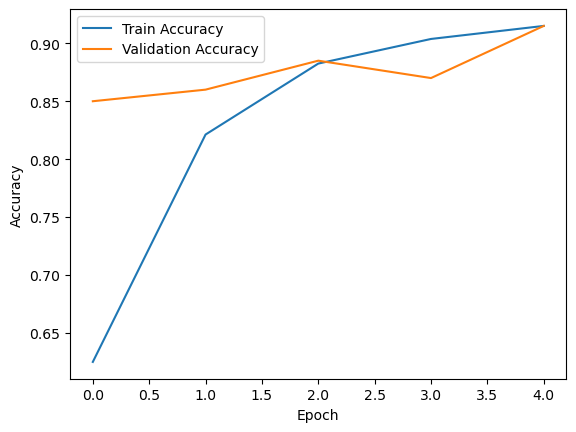

In [10]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Correct Dataset Path
dataset_dir = "dataset"

img_size = (224, 224)
batch_size = 32

# Load Dataset with automatic split
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

# Normalize Data
normalization_layer = layers.Rescaling(1./255)

train_data = train_data.map(lambda x, y: (normalization_layer(x), y))
test_data = test_data.map(lambda x, y: (normalization_layer(x), y))

# Load VGG16 Model
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze Layers
for layer in base_model.layers:
    layer.trainable = False

# Build Model
model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()